
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>

In [ ]:

<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades []! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.


_________________________________________________________________________________________________________________________________


En este proyecto se me plantea como científico o analista de datos. Megaline, una compañía telefónica, me solicita realizar un análisis sobre dos tarifas de prepago.

El objetivo es ajustar el presupuesto de publicidad y tomar una decisión basada en los datos recopilados de sus clientes. Se cuenta con una muestra de 500 clientes, de la cual se conoce su lugar de origen, la tarifa utilizada y datos cuantitativos sobre llamadas, mensajes de texto y consumo de datos móviles.

Mediante el análisis del comportamiento de los clientes, se debe determinar cuál de las dos tarifas resulta más rentable. Esto puede evaluarse principalmente a través del cálculo de la media, aunque también se pueden aplicar filtros específicos según la base de datos.

Además, se calcularán métricas estadísticas como la desviación estándar y la varianza, y se planteará una hipótesis nula que será posteriormente verificada y discutida, con el fin de tomar una decisión debidamente fundamentada.



## Inicialización

In [48]:
# Cargar todas las librerías
import pandas as pd
import seaborn as sns

import numpy as np

from matplotlib import pyplot as plt
from math import factorial
from scipy import stats as st
from scipy.stats import ttest_ind

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo al separar la importación de bibliotecas de la carga de los datasets! Esto mejora la estructura y claridad de tu código.

</div>

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames

df_calls= pd.read_csv('/datasets/megaline_calls.csv')
df_inter = pd.read_csv('/datasets/megaline_internet.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_plans= pd.read_csv('/datasets/megaline_plans.csv')
df_users= pd.read_csv('/datasets/megaline_users.csv')

## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()
df_plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [4]:
# Imprime una muestra de los datos para las tarifas

df_plans.sample()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf


El Data frame "/datasets/megaline_plans.csv" no presenta ningún probelma ni requiere cambios adicionales. Se muestra información de dos planes tarifarios: "Surf" y "Ultimate". No hay datos nulos, los tipos de datos son correctos y las unidades se especifican en los nombres de las columnas. No se detectan problemas, aunque el tamaño del DataFrame es muy pequeño, lo que limita análisis más profundos.

## Corregir datos

In [5]:
#En este dataframe no hay datos ausentes, los tipos de datos son adecuados y se muestran los datos de forma correcta.

## Enriquecer los datos

In [6]:
#No se enriquece el DataFrame en esta etapa, ya que el análisis posterior podría requerir la combinación (por ejemplo, mediante un merge) con otros DataFrames. Esta decisión dependerá de las indicaciones y necesidades que se presenten en las siguientes secciones del proyecto.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy buen uso de métodos como _info_ y _head_ para la exploración de datos. Esto te permitió identificar rápidamente la estructura y posibles problemas de los datos.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como mejora, puedes complementar con análisis de valores únicos o distribuciones preliminares de variables clave.

</div>

</div>

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

df_users.info()
df_users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [8]:
# Imprime una muestra de datos para usuarios

df_users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
475,1475,Arlen,Sutton,66,"Dallas-Fort Worth-Arlington, TX MSA",2018-05-28,ultimate,NaN
465,1465,Arianna,Morrison,73,"Pittsburgh, PA MSA",2018-06-22,ultimate,NaN
218,1218,Stanford,Pena,23,"Bakersfield, CA MSA",2018-01-16,surf,NaN
41,1041,Drucilla,Lynn,58,"Las Vegas-Henderson-Paradise, NV MSA",2018-03-17,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN


El DataFrame df_users contiene información de 500 usuarios, con columnas como user_id, nombre, edad, ciudad, fecha de registro (reg_date), plan contratado y fecha de cancelación (churn_date).
Todos los campos, excepto churn_date, están completos. Solo 34 usuarios tienen una fecha de cancelación, lo que indica que la mayoría (466) aún permanece activa.
Los tipos de datos son apropiados, aunque las columnas ''reg_date' y 'churn_date' aparecen como tipo object y podrían convertirse a datetime para facilitar análisis temporales.

### Corregir los datos

In [9]:
#Se corrige el formato de fecha para posibles análisis futuros

df_users['reg_date']=pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')
df_users['churn_date']=pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d')
df_users.info()

users_duplicados=df_users.duplicated().sum()
print()
print(users_duplicados)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB

0


<div class="alert alert-block alert-success">
<b>Comentario Revisor</b> <a class="tocSkip"></a>

En todos los casos en los que cambiamos el tipo de variable a datetime, siempre es recomendable agregar el argumento "format='%Y-%m-%d'" dentro de la función to_datetime(). De esta manera, puedes asegurarte siempre de que el formato de la fecha que deseas cambiar sea el que necesitas. Excelente!
</div>

### Enriquecer los datos

In [10]:
df_users['days_active'] = (df_users['churn_date'] - df_users['reg_date']).dt.days
print(df_users[pd.notna(df_users['churn_date'])])

print()
df_users.info()

     user_id  first_name  last_name  age  \
6       1006      Jesusa   Bradford   73   
12      1012     Jonelle    Mcbride   59   
22      1022          Bo       Snow   73   
40      1040       Paris     Santos   72   
50      1050        Jone       Owen   23   
54      1054       Denis      Frost   50   
67      1067        Robt      Allen   37   
83      1083      Lyndia    Acevedo   65   
84      1084       Wiley   Mckinney   21   
94      1094      Walter   Petersen   54   
106     1106        Eddy   Garrison   47   
129     1129       Marin     Bolton   70   
172     1172      Weldon   Robinson   72   
180     1180       Wonda       Hays   24   
186     1186      Josiah    Douglas   55   
191     1191        Zack     Waters   75   
220     1220        Jack     Strong   26   
246     1246      Stevie      Moran   69   
269     1269      Irving   Thompson   39   
281     1281        Zack      Hardy   39   
296     1296      Weston     Conley   36   
298     1298       Loyce     Coo

## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

df_calls.info()
print()
df_calls.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB



,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [12]:
# Imprime una muestra de datos para las llamadas

df_calls.sample(5)

,id,user_id,call_date,duration
18389,1071_160,1071,2018-12-12,9.28
104941,1369_26,1369,2018-12-20,10.73
50270,1181_630,1181,2018-11-08,7.11
115990,1406_216,1406,2018-11-25,14.45
134264,1488_428,1488,2018-08-23,6.44


Se pueden observar los ID de llamada y de usuario, los cuales comparten una estructura similar y están separados por un guion bajo. Esto provoca que ambos sean interpretados como tipo object, a pesar de representar valores numéricos.
Además, la columna de fecha también se encuentra como tipo object, por lo que requiere ser convertida al tipo de dato datetime para permitir análisis temporales adecuados.

El ID de usuario se presenta correctamente como número entero, y la duración de las llamadas aparece como un número decimal. Sería útil agrupar los datos por usuario para conocer, por ejemplo, la cantidad total de llamadas realizadas o el total de minutos utilizados, lo cual puede ser relevante para evaluar el uso del plan tarifario.

### Corregir los datos

In [13]:
df_calls['call_date']=pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')

calls_duplicados=df_calls.duplicated().sum()
print()
print(users_duplicados)


0


### Enriquecer los datos

In [14]:
df_calls['calls_month'] = df_calls['call_date'].dt.to_period('M')

calls_resumen = df_calls.groupby(['calls_month', 'user_id']).agg(cantidad_llamadas=('id', 'count'), minutos_usados=('duration', 'sum')).reset_index()
print(calls_resumen[calls_resumen['user_id']==1042])

     calls_month  user_id  cantidad_llamadas  minutos_usados
0        2018-01     1042                 18          106.83
6        2018-02     1042                 37          240.66
24       2018-03     1042                 39          200.48
59       2018-04     1042                 44          264.49
133      2018-05     1042                 51          470.67
240      2018-06     1042                 52          353.99
385      2018-07     1042                 48          349.24
569      2018-08     1042                 44          341.95
797      2018-09     1042                 41          235.98
1080     2018-10     1042                 41          265.16
1423     2018-11     1042                 42          285.82
1835     2018-12     1042                 46          339.13


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Antes de agrupar las llamadas por mes y usuario, debes redondear hacia arriba la duración de cada una de las llamadas. Puedes utilizar `np.ceil` o alguna función similar sobre la columna `duration`. Esto es importante realizarlo antes del `groupby`, ya que si no, los datos agrupados no serían los correctos para el cálculo de ingreso por usuario.

Esto afectará el resto de los cálculos. 

</div>

## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

df_messages.info()
df_messages.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [16]:
# Imprime una muestra de datos para los mensajes

df_messages.sample()

,id,user_id,message_date
26345,1159_348,1159,2018-10-09


En el DataFrame df_messages se observa que el ID del mensaje está compuesto por el ID del usuario y un identificador adicional, separados por un guion bajo. También se incluye la fecha en la que se envió cada mensaje.
El tipo de dato para el user_id es correcto (entero), pero se repite el mismo detalle observado en otros DataFrames: el campo id del mensaje se encuentra como tipo object, al igual que la fecha, por lo que esta última debe convertirse al tipo datetime para permitir futuros análisis temporales.

### Corregir los datos

In [17]:
df_messages['message_date']=pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')

messages_duplicados=df_messages.duplicated().sum()
print()
print(messages_duplicados)


0


### Enriquecer los datos

In [18]:
df_messages['message_date'] = df_messages['message_date'].dt.to_period('M')

messages_resumen = df_messages.groupby(['message_date', 'user_id']).agg(cantidad_mensajes=('id', 'count')).reset_index()
print(messages_resumen)

     message_date  user_id  cantidad_mensajes
0         2018-01     1077                 37
1         2018-01     1196                 23
2         2018-01     1214                  2
3         2018-01     1362                 21
4         2018-02     1028                 12
...           ...      ...                ...
1801      2018-12     1491                 43
1802      2018-12     1492                 37
1803      2018-12     1494                 33
1804      2018-12     1496                 11
1805      2018-12     1497                 50

[1806 rows x 3 columns]


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Puedes utilizar el atributo _name_ del método `reset_index` para especificar un nombre de columna al valor agregado.

</div>

## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_inter.info()
print()
df_inter.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB



,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [20]:
# Imprime una muestra de datos para el tráfico de internet

df_inter.sample()

,id,user_id,session_date,mb_used
14168,1066_57,1066,2018-11-02,0.0


El DataFrame se compone de las sesiones de navegación (id) iniciadas por cada usuario (user_id), indicando la fecha y el consumo de megabytes durante cada sesión. La columna de fecha se encuentra con un tipo de dato incorrecto (object), por lo que debe convertirse a tipo datetime para permitir análisis temporales adecuados.
Como se mencionó anteriormente, los demás datos son correctos, y el id de la sesión no debe modificarse debido a su estructura compuesta.

### Corregir los datos

In [21]:
df_inter['session_date']=pd.to_datetime(df_inter['session_date'], format='%Y-%m-%d')

inter_duplicados=df_inter.duplicated().sum()
print()
print(inter_duplicados)


0


### Enriquecer los datos

In [22]:
df_inter['session_date']= df_inter['session_date'].dt.to_period('M')

inter_resumen = df_inter.groupby(['session_date', 'user_id']).agg(cantidad_mbs=('mb_used', 'sum')).reset_index()
print(inter_resumen)

     session_date  user_id  cantidad_mbs
0         2018-01     1042       1854.93
1         2018-01     1077      10635.64
2         2018-01     1185       6812.77
3         2018-01     1196       8908.61
4         2018-01     1214       1315.35
...           ...      ...           ...
2272      2018-12     1495      24097.40
2273      2018-12     1496      16438.99
2274      2018-12     1497      11106.55
2275      2018-12     1498      23137.69
2276      2018-12     1499      22059.21

[2277 rows x 3 columns]


[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

print(df_plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Bien hecho, convertiste las columnas a los tipos de datos adecuados (fechas, enteros, etc.) e hiciste los cambios esperados. Esto evita errores en cálculos posteriores. 


</div>

## Agregar datos por usuario

In [24]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

#Se toma de ejemplo al usuario "1042", para mostras la cantidad de llamadas realizadas en un mes y minutos de llamada utilizados
print(calls_resumen[calls_resumen['user_id']==1042])

     calls_month  user_id  cantidad_llamadas  minutos_usados
0        2018-01     1042                 18          106.83
6        2018-02     1042                 37          240.66
24       2018-03     1042                 39          200.48
59       2018-04     1042                 44          264.49
133      2018-05     1042                 51          470.67
240      2018-06     1042                 52          353.99
385      2018-07     1042                 48          349.24
569      2018-08     1042                 44          341.95
797      2018-09     1042                 41          235.98
1080     2018-10     1042                 41          265.16
1423     2018-11     1042                 42          285.82
1835     2018-12     1042                 46          339.13


In [25]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

print(calls_resumen)

     calls_month  user_id  cantidad_llamadas  minutos_usados
0        2018-01     1042                 18          106.83
1        2018-01     1077                 42          275.07
2        2018-01     1185                 23          170.29
3        2018-01     1196                 42          272.56
4        2018-01     1214                  5           14.73
...          ...      ...                ...             ...
2253     2018-12     1495                 65          467.47
2254     2018-12     1496                 40          278.61
2255     2018-12     1497                 54          276.53
2256     2018-12     1498                 39          324.77
2257     2018-12     1499                 65          468.10

[2258 rows x 4 columns]


In [26]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

print(messages_resumen)

     message_date  user_id  cantidad_mensajes
0         2018-01     1077                 37
1         2018-01     1196                 23
2         2018-01     1214                  2
3         2018-01     1362                 21
4         2018-02     1028                 12
...           ...      ...                ...
1801      2018-12     1491                 43
1802      2018-12     1492                 37
1803      2018-12     1494                 33
1804      2018-12     1496                 11
1805      2018-12     1497                 50

[1806 rows x 3 columns]


In [27]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

print(inter_resumen)

     session_date  user_id  cantidad_mbs
0         2018-01     1042       1854.93
1         2018-01     1077      10635.64
2         2018-01     1185       6812.77
3         2018-01     1196       8908.61
4         2018-01     1214       1315.35
...           ...      ...           ...
2272      2018-12     1495      24097.40
2273      2018-12     1496      16438.99
2274      2018-12     1497      11106.55
2275      2018-12     1498      23137.69
2276      2018-12     1499      22059.21

[2277 rows x 3 columns]


In [28]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
calls_final = calls_resumen.rename(columns={'calls_month': 'month'})
messages_final=messages_resumen.rename(columns={'message_date': 'month'})
inter_final=inter_resumen.rename(columns={'session_date': 'month'})

df_temp1 = calls_final.merge(messages_final, on=['user_id', 'month'], how='outer')
df_temp2= df_temp1.merge(inter_final, on=['user_id', 'month'], how='outer')

In [29]:
# Añade la información de la tarifa
users_resumen = df_users[['user_id', 'age', 'city', 'plan']]
df_final= df_temp2.merge(users_resumen, on='user_id', how='outer')

print(df_final[df_final['user_id']==1077])

      month  user_id  cantidad_llamadas  minutos_usados  cantidad_mensajes  \
12  2018-01     1077               42.0          275.07               37.0   
13  2018-02     1077              111.0          737.25               67.0   
14  2018-03     1077              107.0          663.16               72.0   
15  2018-04     1077               95.0          703.19               57.0   
16  2018-05     1077               85.0          625.09               77.0   
17  2018-06     1077              100.0          673.14               81.0   
18  2018-07     1077              110.0          763.84               73.0   
19  2018-08     1077              132.0          685.61               79.0   
20  2018-09     1077              119.0          804.84               63.0   
21  2018-10     1077               89.0          502.45               63.0   
22  2018-11     1077              125.0          793.02               56.0   
23  2018-12     1077              109.0          797.43         

<div class="alert alert-block alert-danger"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Al unir los nuevos datasets con los datos principales, lo correcto es utilizar _left_ join, ya que la data de consumo de usuarios está completa y debe mantenerse.

</div>

[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [30]:
# Calcula el ingreso mensual para cada usuario

columnas_numericas=['cantidad_llamadas', 'minutos_usados', 'cantidad_mensajes', 'cantidad_mbs']
df_final[columnas_numericas] = df_final[columnas_numericas].fillna(0)

def calcular_costos_llamadas(fila):
    if fila['plan'] == 'surf':
        extra = max(fila['minutos_usados'] - 500, 0)
        return extra*0.03
    elif fila['plan'] == 'ultimate':
        extra = max(fila['minutos_usados'] - 3000, 0)
        return extra*0.01
    else:
        return 0


def calcular_costos_mensajes(fila):
    if fila['plan']=='surf':
        extra=max(fila['cantidad_mensajes'] - 50, 0)
        return extra *0.03
    elif fila['plan']=='ultimate':
        extra=max(fila['cantidad_mensajes'] - 1000, 0)
        return extra *0.01
    else:
        return 0


import math
def calcular_costos_inter(fila):
    if fila['plan']=='surf':
        exceso_mb = max(fila['cantidad_mbs'] - 15360, 0)
        exceso_gb = math.ceil(exceso_mb/1024)
        return exceso_gb * 10
    elif fila['plan']=='ultimate':
        exceso_mb = max(fila['cantidad_mbs'] - 30720, 0)
        exceso_gb = math.ceil(exceso_mb /1024)
        return exceso_gb * 7
    else:
        return 0

def calcular_total_mensual(fila):
    if fila['plan']=='surf':
        extra=max(fila['cantidad_mensajes'] - 50, 0)
        return extra *0.03
    elif fila['plan']=='ultimate':
        extra=max(fila['cantidad_mensajes'] - 1000, 0)
        return extra *0.01
    else:
        return 0


def costo_total(fila):
    suma =fila['costo_llamadas'] + fila['costo_mensajes'] + fila['costo_mb']
    if fila['plan']=='surf':
        return suma + 20
    elif fila['plan']=='ultimate':
        return suma + 70
    else:
        return suma


df_final['costo_llamadas']=df_final.apply(calcular_costos_llamadas, axis=1)
df_final['costo_mensajes']=df_final.apply(calcular_costos_mensajes, axis=1)
df_final['costo_mb']=df_final.apply(calcular_costos_inter, axis=1)
df_final['costo_total']=df_final.apply(costo_total, axis=1)

print(df_final.sample(5))

        month  user_id  cantidad_llamadas  minutos_usados  cantidad_mensajes  \
571   2018-04     1291               12.0           74.38                2.0   
1464  2018-10     1097              104.0          652.71                0.0   
580   2018-04     1320               71.0          422.54               27.0   
1138  2018-06     1384               27.0          170.08               59.0   
146   2018-02     1408               53.0          419.85               29.0   

      cantidad_mbs  age                                              city  \
571        3779.34   65              Indianapolis-Carmel-Anderson, IN MSA   
1464      17220.95   27  Washington-Arlington-Alexandria, DC-VA-MD-WV MSA   
580        8356.98   23            Los Angeles-Long Beach-Anaheim, CA MSA   
1138      15320.45   36   Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA   
146       11828.25   40                 Baltimore-Columbia-Towson, MD MSA   

          plan  costo_llamadas  costo_mensajes  costo_mb

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Calculaste correctamente las métricas mensuales por usuario (llamadas, SMS, datos e ingresos). Esto es clave para comparar planes.


</div>

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

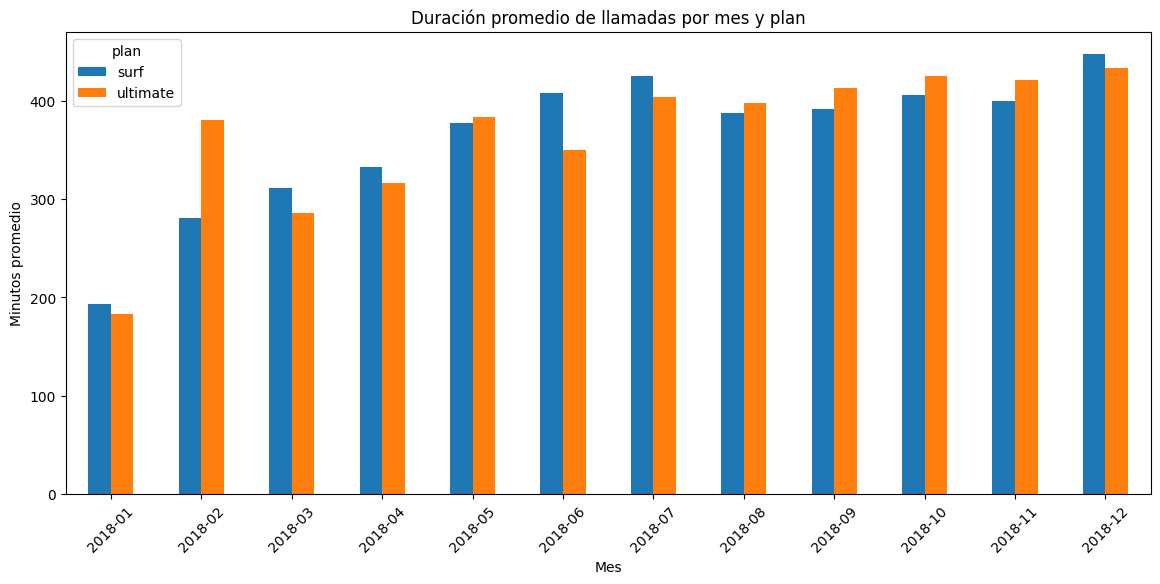

In [31]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

llamadas_plan = df_final.groupby(['plan', 'month'])['minutos_usados'].mean()

llamadas_plan_unstack = llamadas_plan.unstack(level=0)
llamadas_plan_unstack.plot(kind='bar', figsize=(14,6), title='Duración promedio de llamadas por mes y plan', xlabel='Mes', ylabel='Minutos promedio', rot=45)
plt.show()


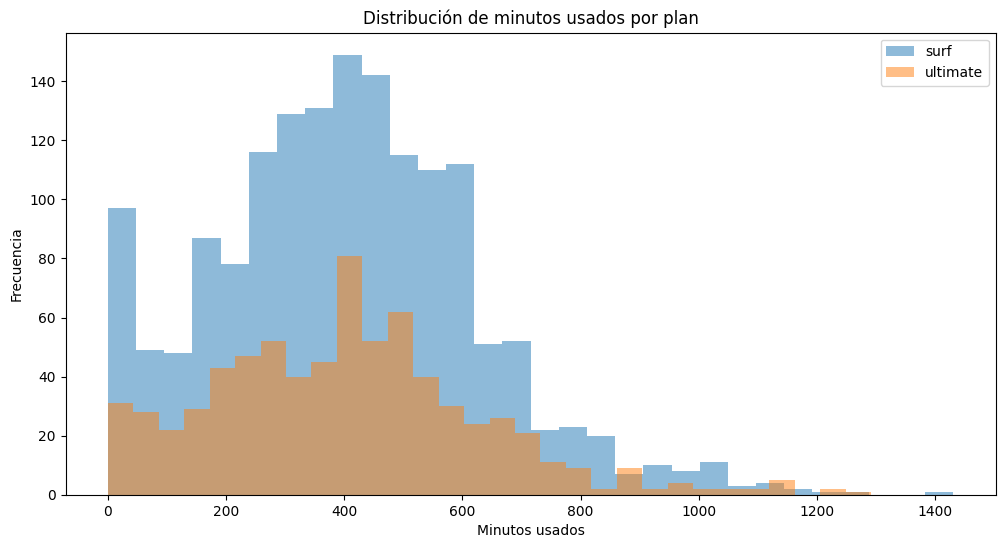

In [32]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

df_final.groupby('plan')['minutos_usados'].plot(kind='hist', alpha=0.5, bins=30, legend=True, figsize=(12,6), title='Distribución de minutos usados por plan')
plt.xlabel('Minutos usados')
plt.ylabel('Frecuencia')
plt.show()

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [33]:
# Calcula la media y la varianza de la duración mensual de llamadas.
min_varianza = df_final.groupby('month')['minutos_usados'].var()
min_nedia =df_final.groupby('month')['minutos_usados'].mean()
print(min_varianza)
print(min_nedia)

month
2018-01    11978.884417
2018-02    55034.331430
2018-03    38297.559553
2018-04    40857.825162
2018-05    49052.952900
2018-06    40290.973822
2018-07    57598.688315
2018-08    48145.862318
2018-09    44405.688995
2018-10    47179.463884
2018-11    48599.640860
2018-12    56522.142408
Freq: M, Name: minutos_usados, dtype: float64
month
2018-01    186.388333
2018-02    324.168125
2018-03    302.306571
2018-04    327.685493
2018-05    378.862075
2018-06    388.474861
2018-07    417.719889
2018-08    390.248884
2018-09    397.839893
2018-10    411.711079
2018-11    406.066829
2018-12    442.818849
Freq: M, Name: minutos_usados, dtype: float64


<div class="alert alert-block alert-danger"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Faltan los cálculos de medidas estadísticas básicas. Sin ellas no se puede comparar la dispersión y el promedio de uso entre planes. Asegúrate de incluir al menos media, varianza y desviación estándar.

</div>

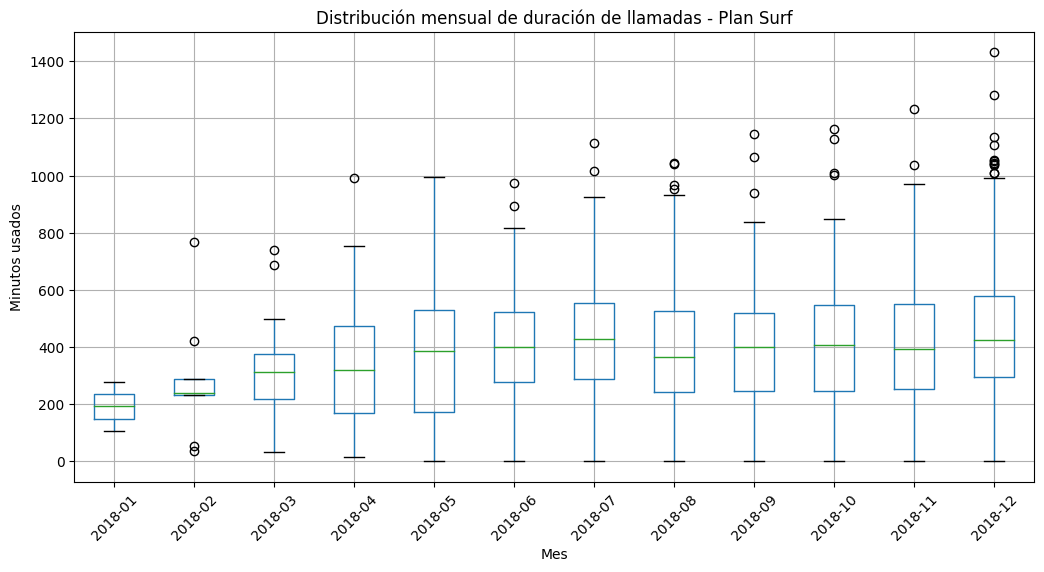

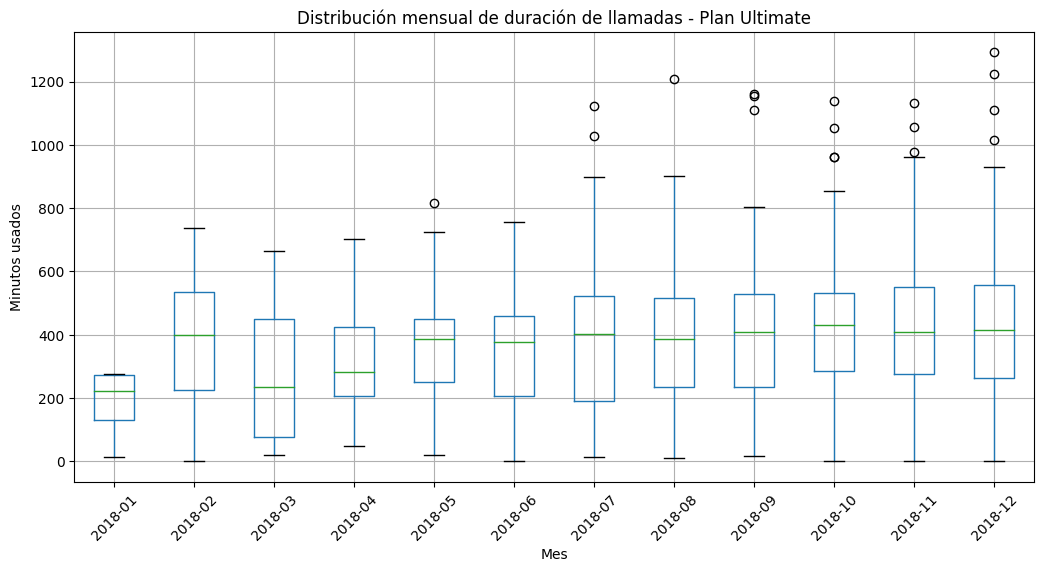

In [34]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

df_final[df_final['plan'] == 'surf'].boxplot(column='minutos_usados', by='month', figsize=(12, 6))
plt.title('Distribución mensual de duración de llamadas - Plan Surf')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Minutos usados')
plt.xticks(rotation=45)
plt.show()

df_final[df_final['plan'] == 'ultimate'].boxplot(column='minutos_usados', by='month', figsize=(12, 6))
plt.title('Distribución mensual de duración de llamadas - Plan Ultimate')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Minutos usados')
plt.xticks(rotation=45)
plt.show()

El comportamiento de los usuarios con respecto a las llamadas varía según el plan contratado. En general, los usuarios del plan Ultimate presentan una duración de llamadas más estable a lo largo de los meses, con menos dispersión y valores atípicos, lo que indica un uso más predecible y cubierto dentro de los límites del plan. Por otro lado, los usuarios del plan Surf muestran una mayor variabilidad en la duración de las llamadas mensuales y una presencia considerable de valores atípicos, lo cual sugiere que sus necesidades no siempre se ajustan a lo que ofrece el plan. De forma concisa, se puede concluir que los usuarios del plan Surf tienden a sobrepasar más frecuentemente los límites de minutos incluidos en comparación con los del plan Ultimate.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Bien hecho, todos los graficos son correctos y permiten visualizar las distribuciones y detectar sesgos o valores atípicos. 

</div>

### Mensajes

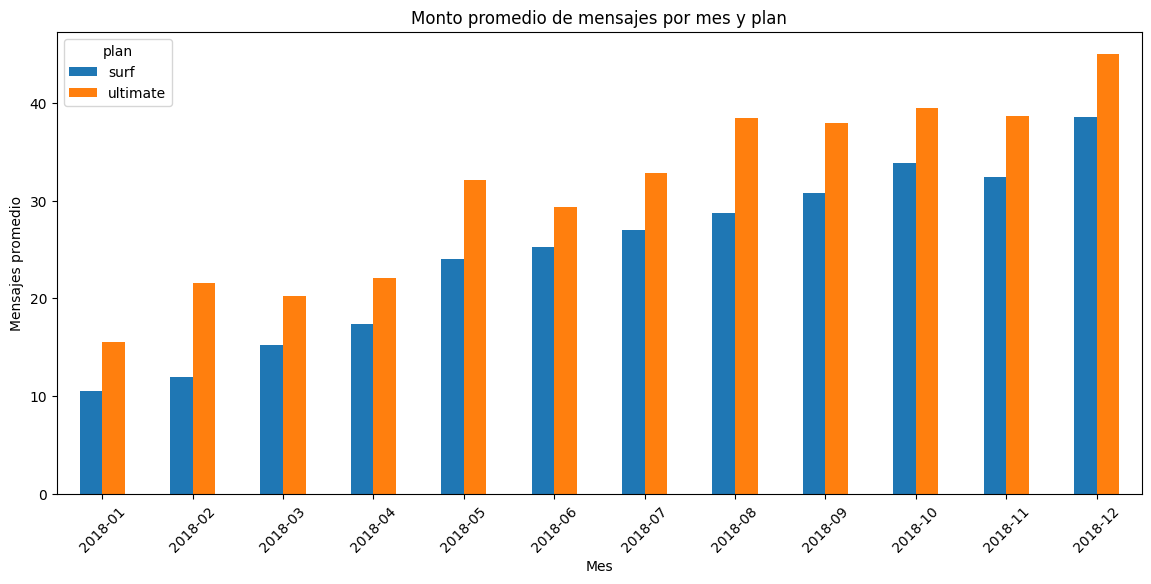

In [35]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

mensajes_plan = df_final.groupby(['plan', 'month'])['cantidad_mensajes'].mean()

mensajes_plan_unstack = mensajes_plan.unstack(level=0)
mensajes_plan_unstack.plot(kind='bar', figsize=(14,6), title='Monto promedio de mensajes por mes y plan', xlabel='Mes', ylabel='Mensajes promedio', rot=45)
plt.show()

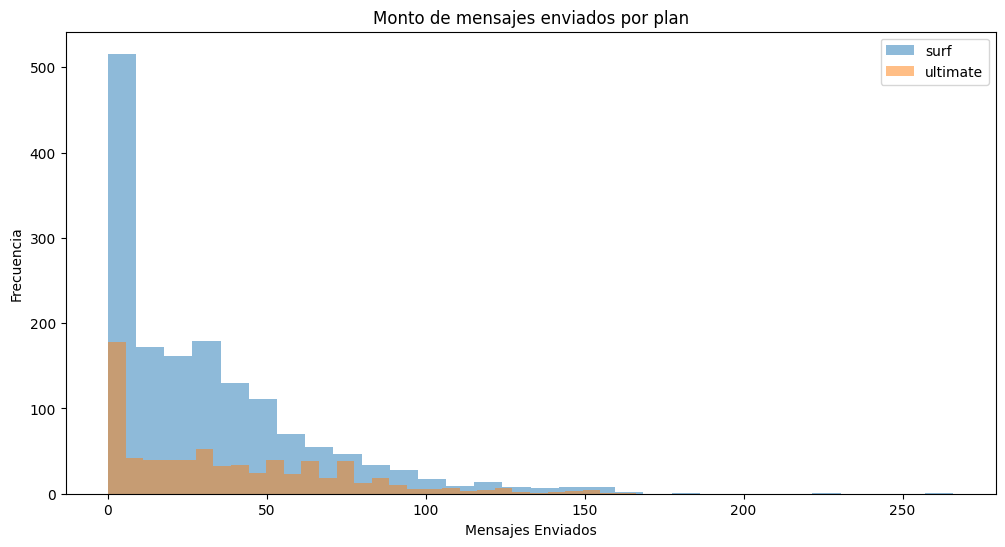




month
2018-01     238.966667
2018-02     421.229167
2018-03     441.734454
2018-04     511.148491
2018-05     972.291105
2018-06     893.706245
2018-07     938.051397
2018-08    1095.446130
2018-09    1025.442281
2018-10    1261.771930
2018-11    1122.582003
2018-12    1493.270880
Freq: M, Name: cantidad_mensajes, dtype: float64
month
2018-01    13.833333
2018-02    16.187500
2018-03    16.971429
2018-04    18.774648
2018-05    26.226415
2018-06    26.618056
2018-07    28.933333
2018-08    31.733906
2018-09    32.953571
2018-10    35.571429
2018-11    34.312195
2018-12    40.663113
Freq: M, Name: cantidad_mensajes, dtype: float64


In [36]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
#*********Aquí lo solicita en esta sección  de "mensajes" pero más abajo lo "hace" nuevamente,, lo pondré abajo, en esta sección, sólo me enfocaré en mensajes**********

df_final.groupby('plan')['cantidad_mensajes'].plot(kind='hist', alpha=0.5, bins=30, legend=True, figsize=(12,6), title='Monto de mensajes enviados por plan')
plt.xlabel('Mensajes Enviados')
plt.ylabel('Frecuencia')
plt.show()

print()
print()
print()

mensj_varianza = df_final.groupby('month')['cantidad_mensajes'].var()
mensj_nedia =df_final.groupby('month')['cantidad_mensajes'].mean()
print(mensj_varianza)
print(mensj_nedia)

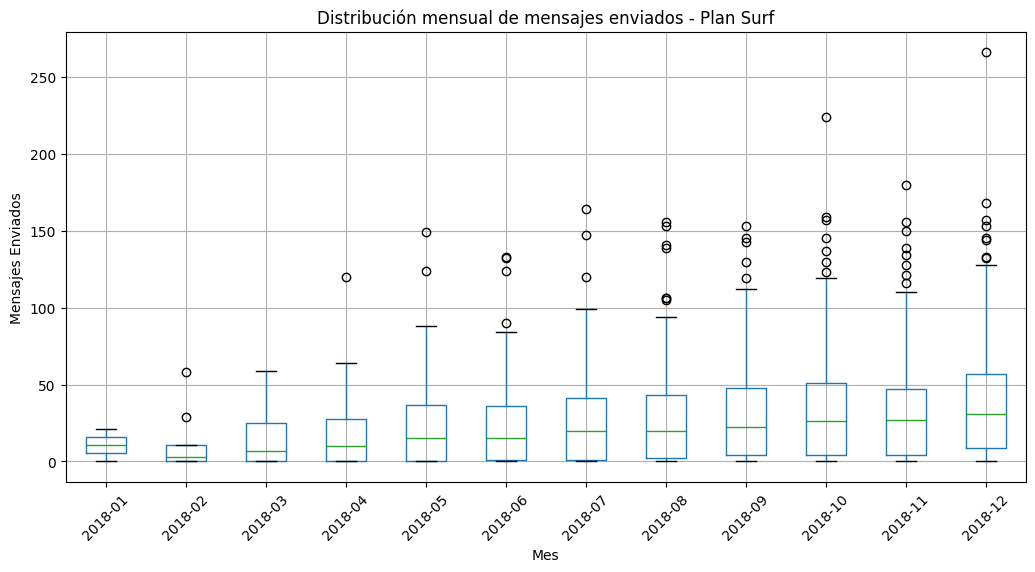

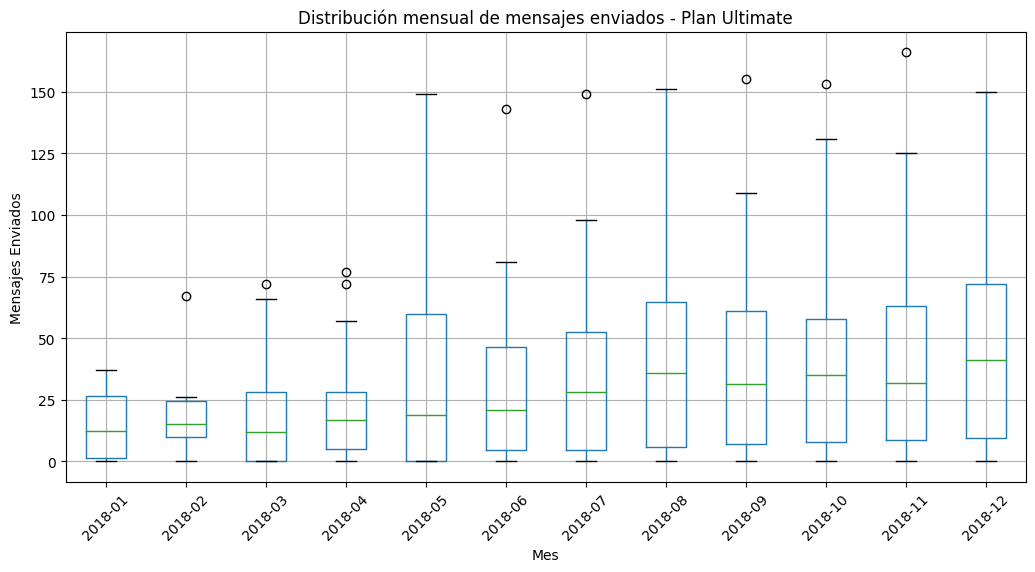

In [37]:
#aquí no había comentarío así que sólo hice lo que previemente se me solicitó 

df_final[df_final['plan'] == 'surf'].boxplot(column='cantidad_mensajes', by='month', figsize=(12, 6))
plt.title('Distribución mensual de mensajes enviados - Plan Surf')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Mensajes Enviados')
plt.xticks(rotation=45)
plt.show()

df_final[df_final['plan'] == 'ultimate'].boxplot(column='cantidad_mensajes', by='month', figsize=(12, 6))
plt.title('Distribución mensual de mensajes enviados - Plan Ultimate')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Mensajes Enviados')
plt.xticks(rotation=45)
plt.show()


Las gráficas reflejan que los usuarios del plan Surf tienden a enviar una mayor cantidad de mensajes mensuales con una variabilidad considerable, mostrando picos altos y una dispersión amplia en sus patrones de uso. En contraste, los usuarios del plan Ultimate presentan un comportamiento más estable y moderado, con menores cantidades promedio de mensajes y menos fluctuaciones a lo largo del tiempo. Esto indica que el comportamiento en el envío de mensajes varía según el plan contratado, probablemente debido a diferencias en las necesidades o beneficios asociados a cada uno.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente, describiste de manera clara las distribuciones y sus implicaciones.

</div>

### Internet

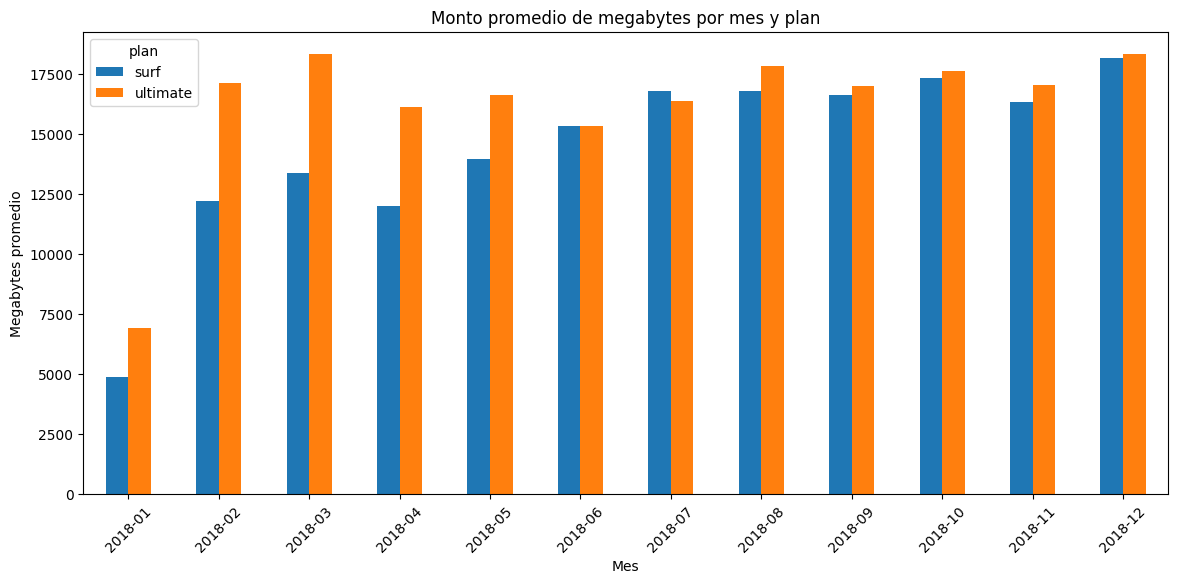

In [38]:
inter_plan = df_final.groupby(['plan', 'month'])['cantidad_mbs'].mean()

inter_plan_unstack = inter_plan.unstack(level=0)
inter_plan_unstack.plot(kind='bar', figsize=(14,6), title='Monto promedio de megabytes por mes y plan', xlabel='Mes', ylabel='Megabytes promedio', rot=45)
plt.show()

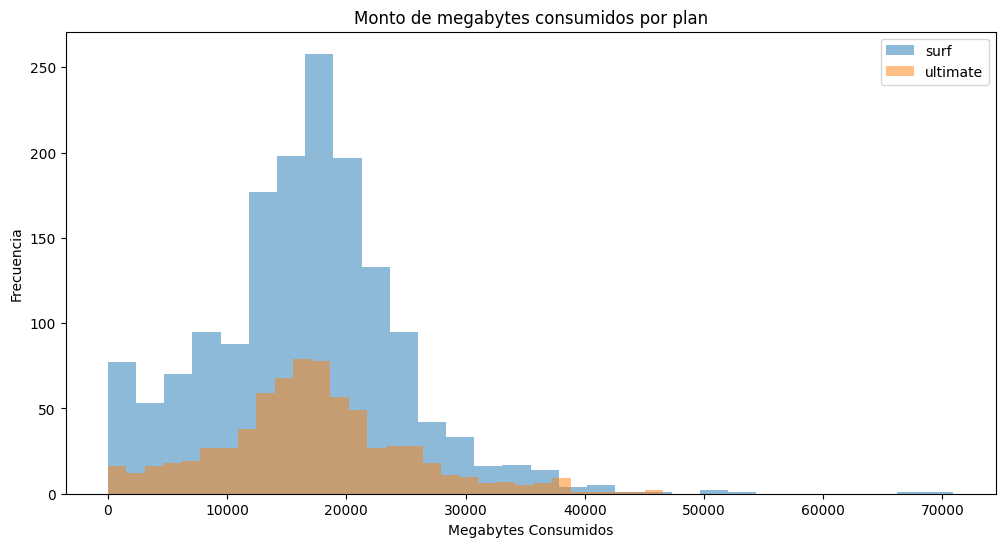




month
2018-01    1.459810e+07
2018-02    4.478370e+07
2018-03    9.530571e+07
2018-04    7.021336e+07
2018-05    6.109108e+07
2018-06    5.615046e+07
2018-07    6.557731e+07
2018-08    7.025460e+07
2018-09    5.056081e+07
2018-10    6.066592e+07
2018-11    5.726658e+07
2018-12    6.871079e+07
Freq: M, Name: cantidad_mbs, dtype: float64
month
2018-01     6237.015000
2018-02    14344.453125
2018-03    15051.524000
2018-04    13207.956338
2018-05    14671.786038
2018-06    15313.407083
2018-07    16639.753278
2018-08    17105.960558
2018-09    16707.665893
2018-10    17404.422945
2018-11    16554.358634
2018-12    18193.874691
Freq: M, Name: cantidad_mbs, dtype: float64


In [39]:
df_final.groupby('plan')['cantidad_mbs'].plot(kind='hist', alpha=0.5, bins=30, legend=True, figsize=(12,6), title='Monto de megabytes consumidos por plan')
plt.xlabel('Megabytes Consumidos')
plt.ylabel('Frecuencia')
plt.show()

print()
print()
print()

inter_varianza = df_final.groupby('month')['cantidad_mbs'].var()
inter_nedia =df_final.groupby('month')['cantidad_mbs'].mean()
print(inter_varianza)
print(inter_nedia)

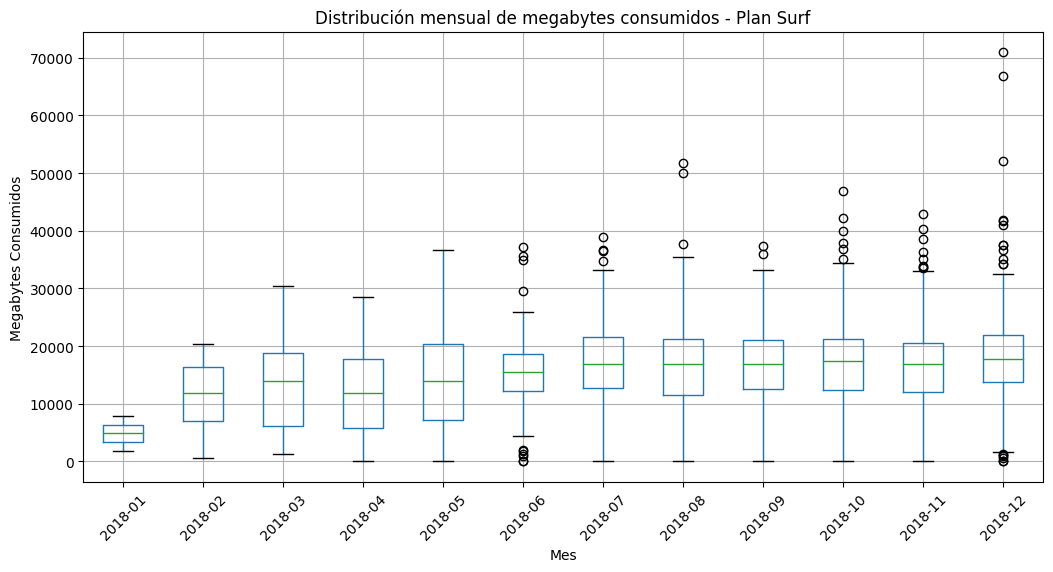

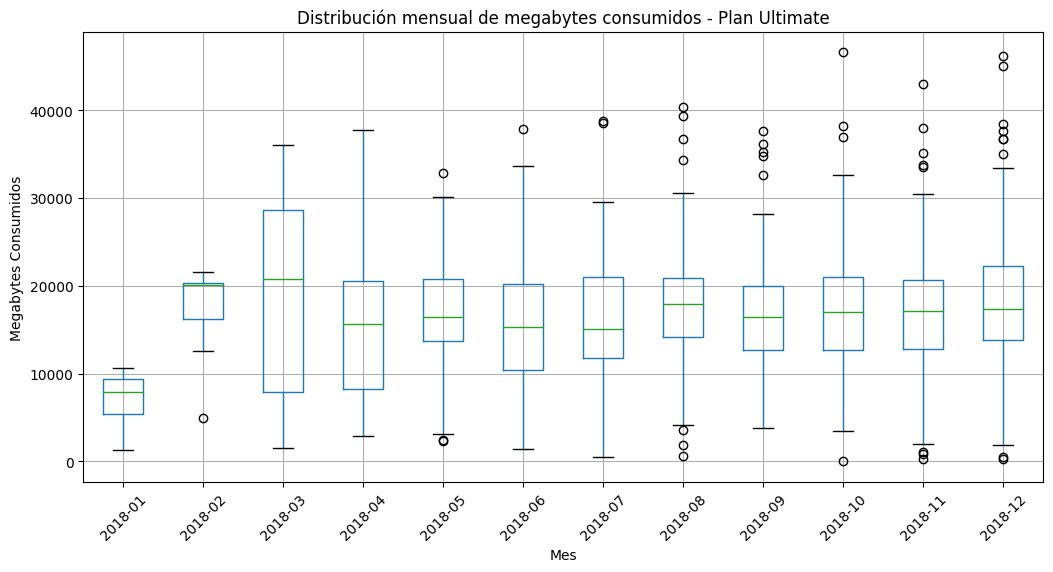

In [40]:
df_final[df_final['plan'] == 'surf'].boxplot(column='cantidad_mbs', by='month', figsize=(12, 6))
plt.title('Distribución mensual de megabytes consumidos - Plan Surf')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Megabytes Consumidos')
plt.xticks(rotation=45)
plt.show()

df_final[df_final['plan'] == 'ultimate'].boxplot(column='cantidad_mbs', by='month', figsize=(12, 6))
plt.title('Distribución mensual de megabytes consumidos - Plan Ultimate')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Megabytes Consumidos')
plt.xticks(rotation=45)
plt.show()

Los usuarios de ambos planes muestran una variabilidad considerable en el consumo mensual de megabytes, pero se pueden notar algunas diferencias en su comportamiento. Los usuarios del plan Surf tienden a tener un consumo más alto y más disperso, con valores máximos mucho mayores y un rango intercuartílico más amplio, lo que indica que algunos usuarios sobrepasan notablemente los límites típicos del plan. En contraste, los usuarios del plan Ultimate presentan un consumo más estable y concentrado en un rango menor, con menos valores extremos, sugiriendo un uso más moderado y consistente del tráfico de Internet. Por lo tanto, el comportamiento de consumo sí varía según el plan, siendo los usuarios del plan Surf los que suelen consumir más megabytes y con mayor dispersión, mientras que los del plan Ultimate mantienen un patrón de consumo más uniforme y controlado.

## Ingreso

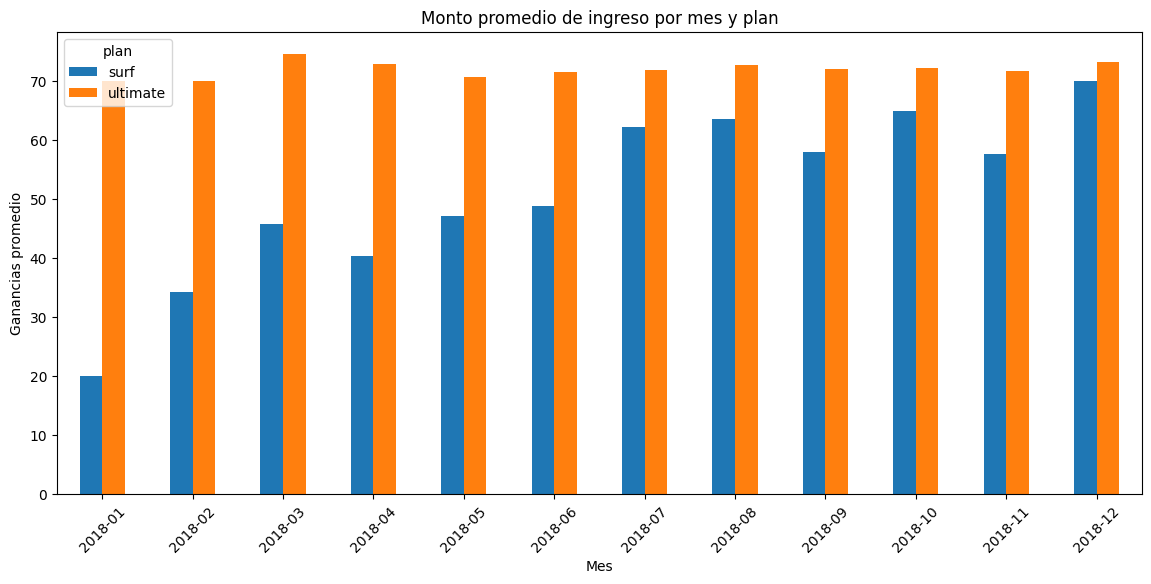

In [41]:
costo_plan = df_final.groupby(['plan', 'month'])['costo_total'].mean()

costo_plan_unstack = costo_plan.unstack(level=0)
costo_plan_unstack.plot(kind='bar', figsize=(14,6), title='Monto promedio de ingreso por mes y plan', xlabel='Mes', ylabel='Ganancias promedio', rot=45)
plt.show()

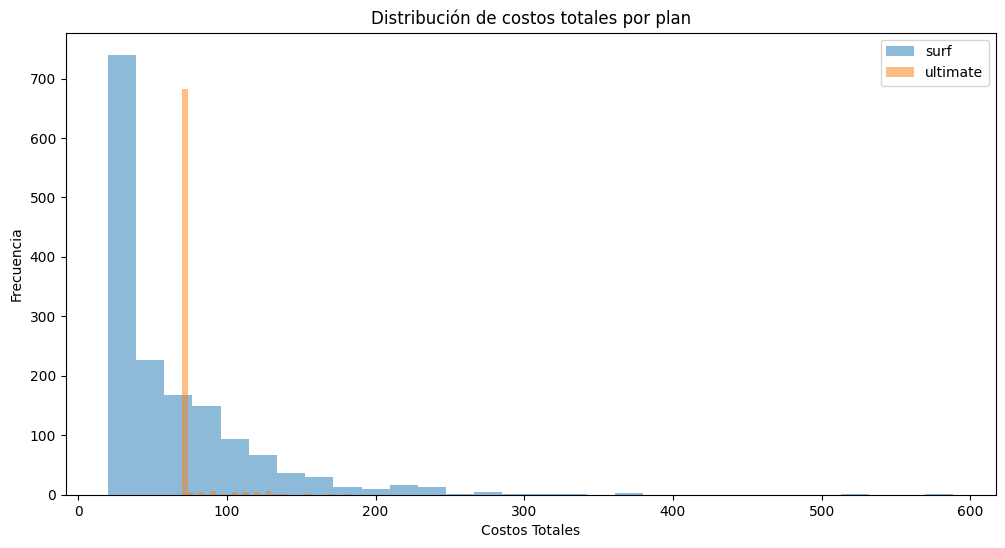




plan      month  
surf      2018-01       0.000000
          2018-02     429.972008
          2018-03    1507.606780
          2018-04    1196.879428
          2018-05    1949.819080
          2018-06    1977.719697
          2018-07    2921.294737
          2018-08    3572.648825
          2018-09    2252.218077
          2018-10    3179.188681
          2018-11    2485.276813
          2018-12    4590.574002
ultimate  2018-01       0.000000
          2018-02       0.000000
          2018-03     145.515152
          2018-04     120.400000
          2018-05      15.206897
          2018-06      75.018501
          2018-07     104.472238
          2018-08     154.808451
          2018-09      75.939945
          2018-10     169.606918
          2018-11      94.668416
          2018-12     212.861192
Name: costo_total, dtype: float64

plan      month  
surf      2018-01    20.000000
          2018-02    34.256733
          2018-03    45.790261
          2018-04    40.454700
          

In [42]:
df_final.groupby('plan')['costo_total'].plot(kind='hist', alpha=0.5, bins=30, legend=True, figsize=(12,6), title='Distribución de costos totales por plan')
plt.xlabel('Costos Totales')
plt.ylabel('Frecuencia')
plt.show()

print()
print()
print()

ganancias_varianza = df_final.groupby(['plan', 'month'])['costo_total'].var()
ganancias_media = df_final.groupby(['plan', 'month'])['costo_total'].mean()
print(ganancias_varianza)
print()
print(ganancias_media)

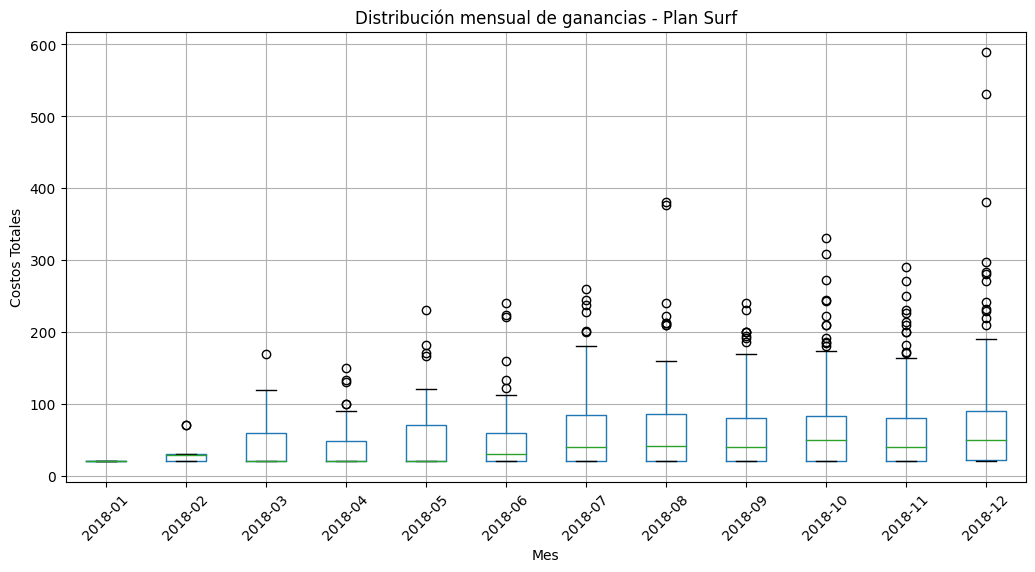

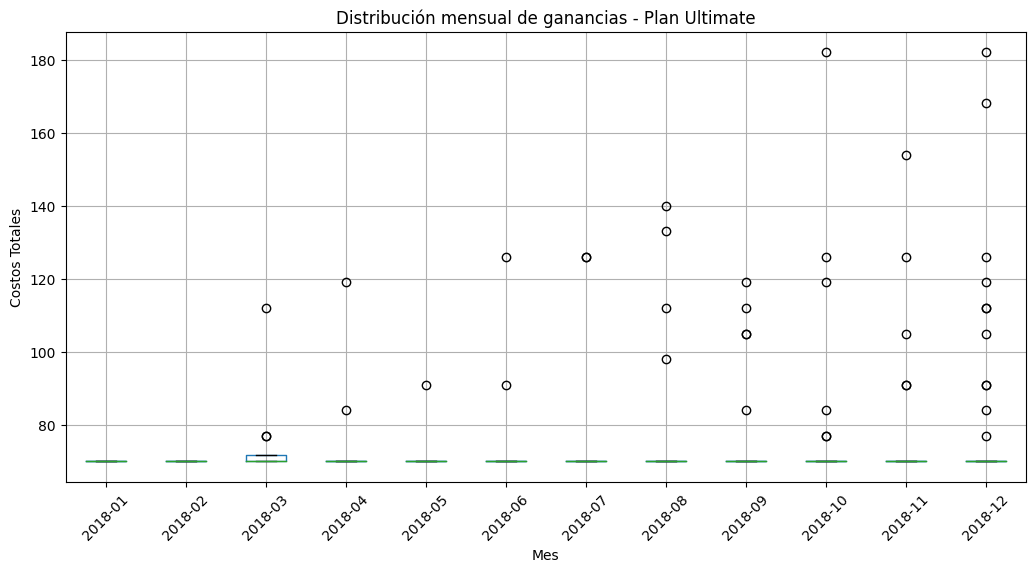

In [43]:
df_final[df_final['plan'] == 'surf'].boxplot(column='costo_total', by='month', figsize=(12, 6))
plt.title('Distribución mensual de ganancias - Plan Surf')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Costos Totales')
plt.xticks(rotation=45)
plt.show()

df_final[df_final['plan'] == 'ultimate'].boxplot(column='costo_total', by='month', figsize=(12, 6))
plt.title('Distribución mensual de ganancias - Plan Ultimate')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Costos Totales')
plt.xticks(rotation=45)
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Vemos que los planes se diferencian en el ingreso, a pesar de que el consumo de sus usuarios es muy similar. Esto ocurre porque la estructura de costos de cada plan define intervalos de consumo diferentes, para surf los usuarios tienden a salirse de esos rangos pero los de ultimate no.

</div>

Los usuarios del plan Surf presentan una mayor variabilidad en los costos mensuales, con frecuencias altas de sobrepasar los límites del plan, especialmente en la segunda mitad del año. En cambio, los usuarios del plan Ultimate mantienen costos estables cercanos al precio fijo del plan, mostrando un comportamiento más predecible y controlado.

## Prueba las hipótesis estadísticas

Hipótesis nula (H₀):
Los ingresos promedio de los usuarios del plan Ultimate y Surf no son significativamente diferentes.
(μ₁ = μ₂)

Hipótesis alternativa (H₁):
Los ingresos promedio de los usuarios del plan Ultimate y Surf son significativamente diferentes.
(μ₁ ≠ μ₂)

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Planteaste las hipótesis de manera formal y clara. Esto demuestra rigor metodológico.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Un consejo: escribe siempre las hipótesis en lenguaje estadístico y en lenguaje simple para mayor claridad.

</div>

</div>

In [46]:
# Prueba las hipótesis


surf_costs = df_final[df_final['plan'] == 'surf']['costo_total']
ultimate_costs = df_final[df_final['plan'] == 'ultimate']['costo_total']
t_stat, p_value = st.ttest_ind(surf_costs, ultimate_costs, equal_var=False)

print("Estadístico t:", t_stat)
print("Valor p:", p_value)

Estadístico t: -8.350445967224664
Valor p: 1.3155784050676364e-16


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy bien, seleccionaste un test estadístico coherente y lo aplicaste correctamente.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como mejora, explica siempre por qué elegiste ese test y qué supuestos tiene.

Además, recuerda que al realizar una prueba de hipótesis, es muy importante verificar los supuestos. El t-test que usaste funciona bien cuando se cumplen ciertos supuestos, como que las varianzas de ambos grupos (sábados lluviosos y no lluviosos) sean similares. Puedes realizar la prueba de levene para comprobar que los dos grupos tienen la misma varianza y, de esta forma, podrás saber el valor del parámetro equal_var que se debe utilizar en la función stats.ttest_ind.

</div>

</div>

Dado que el valor p obtenido (1.32e-16) es considerablemente menor que el nivel de significancia α = 0.05, se rechaza la hipótesis nula. Por lo tanto, se concluye que existe una diferencia estadísticamente significativa en los ingresos promedio de los usuarios de los planes Ultimate y Surf.

Hipótesis nula (H₀):
El ingreso promedio de los usuarios del área de Nueva York y Nueva Jersey (NY-NJ) no es diferente al ingreso promedio de los usuarios de otras regiones.
(μ₁ = μ₂)

Hipótesis alternativa (H₁):
El ingreso promedio de los usuarios del área NY-NJ sí es diferente al de los usuarios de otras regiones.
(μ₁ ≠ μ₂)


In [49]:
# Prueba las hipótesis

ny_nj_usuarios = df_final[df_final['city'].str.contains('New York|NY-NJ|Newark|Jersey', case=False, na=False)]

# Filtrar usuarios de otras regiones
otros_usuarios = df_final[~df_final['city'].str.contains('New York|NY-NJ|Newark|Jersey', case=False, na=False)]

# Obtener los ingresos promedio (costo_total)
ny_nj_costos = ny_nj_usuarios['costo_total']
otros_costos = otros_usuarios['costo_total']

# Realizar prueba t de Student (con varianzas desiguales)
estadistico, valor_p = ttest_ind(ny_nj_costos, otros_costos, equal_var=False)

print(f"Estadístico t: {estadistico}")
print(f"Valor p: {valor_p}")

Estadístico t: -2.1010671658436464
Valor p: 0.03607753502263239


Dado que el valor p (0.036) es menor al nivel de significancia de 0.05, se rechaza la hipótesis nula. Esto indica que hay una diferencia estadísticamente significativa entre los ingresos promedio de los usuarios del área NY-NJ y los de otras regiones.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Interpretaste los resultados con claridad, explicando su significado práctico.

Recuerda que la estadística es un medio, lo importante es qué significa para el negocio.

</div>

## Conclusión general

Se llevó a cabo un análisis completo del comportamiento de los usuarios móviles a partir de los datos de uso mensual. Se realizó una limpieza cuidadosa del conjunto de datos, tratando los valores faltantes únicamente en columnas numéricas para evitar errores. Posteriormente, se agruparon los datos por usuario y mes, calculando la duración total de llamadas, cantidad de mensajes, uso de internet y costos mensuales, según las condiciones de cada plan. Se generaron visualizaciones como gráficos de barras, histogramas y diagramas de caja para comparar tendencias de consumo, variabilidad y comportamiento por plan y región. Estas representaciones mostraron que los usuarios del plan Surf tienden a superar los límites incluidos con mayor frecuencia, generando costos variables, mientras que los usuarios del plan Ultimate presentan mayor estabilidad y costos más altos en promedio. Finalmente, se aplicaron pruebas t para comparar los ingresos promedio entre planes y regiones, encontrando diferencias estadísticamente significativas. En conclusión, el plan Ultimate resulta más redituable para la empresa debido a sus mayores ingresos promedio y menor variabilidad en costos, a pesar de que el plan Surf presenta usuarios con consumo más variable y ocasionalmente más altos costos.